**Abstract** \
Active matter systems—collections of self-propelled particles that convert energy into directed motion—appear throughout biophysics, from swimming bacteria to motor proteins. Hexbugs, small vibration-driven toy robots, serve as a convenient macroscopic analog for studying active particle behavior. This project developed a node-segment bug and elastic ring simulation to investigate how boundary confinement affects the stability and collective behavior of hexbugs. The model incorporated active self-propulsion, viscous damping, rotational and translational noise, and Coulomb friction, with collisions handled through an impulse-based contact scheme between the bug and ring. The simulation was built iteratively, progressing from a spring-mass bug with a purely elastic ring to a rigid bug driven by a motor force, and finally calibrated against real hexbug data across stationary and moving ring conditions.

Using metrics including median incidence angle, bounce-back fraction, occupancy radius, and orbital reversal rate, we compared hexbug behavior between fixed and moving ring boundaries, and between single- and two-bug systems. Results showed that hexbugs confined to a moving ring exhibited more stable motion than those confined to a stationary boundary, contrary to typical assumptions about fixed confinement. Additionally, introducing a second bug decreased rather than increased system stability. Simulated hexbugs also displayed pronounced wall-hugging behavior, suggesting the model may underestimate the torque exerted by wall collisions relative to real-world dynamics. These findings motivate further refinement of the collision model and continued investigation into the mechanisms driving instability in multi-bug systems.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
import matplotlib

matplotlib.rcParams['animation.embed_limit'] = 150

# Hexbug
m_bug  = 0.00752 / 3        # mass per node [kg]
length = 0.04445            # total length [m]  (1.75 in, real hexbug)
L0     = length / 2         # nodes 1 and 3 sit at ±L0 from CM; node 2 is at CM
M_bug  = 3 * m_bug          # total mass [kg]
I_bug  = 2 * m_bug * L0**2  # moment of inertia

# Ring
ring_fixed = True

R_ring = 0.066675      # radius [m]  (2.625 in, real ring)
M_ring = 0.02334       # total mass [kg]
I_ring = M_ring * R_ring**2   # moment of inertia [kg·m²]

# HARD-WALL impulsive collision
e_rest  = 0.8          
mu_fric = 0.2       
r_cut   = 0.06 * R_ring  

# HARD bug↔bug impulsive collision
e_rest_bb = e_rest   
mu_fric_bb = mu_fric   
r_cut_bug  = 0.6 * L0  

#  Collision noise 
sigma_ang_coll   = np.deg2rad(7.0)  
coll_noise_seed  = 1              

# Friction / Damping 
gamma_bug   = 0.8   # hexbug damping [kg/s]  (locked value, shared by both bugs)
gamma_ring  = 40.0  # ring damping [kg/s] — only used when ring_fixed=False

# Initial kick
v0         = 0.175
theta_kick = np.deg2rad(0)

# Motor 
v_motor = 0.17 * (20 + gamma_bug) / 20   # = 0.1768 at gamma_bug=0.8
k_motor = 20    # responsiveness [1/s]

# Langevin noise 
sigma_om   = 0.5185 # rotational
sigma_v    = 0.13   # translational
noise_seed = 0

# Integration & animation 
t_end = 180.0
FPS   = 30

#  STATE VECTOR 
#  y[0:6]   bug1  [x_cm, y_cm, theta, vx_cm, vy_cm, omega]
#  y[6:12]  bug2  [x_cm, y_cm, theta, vx_cm, vy_cm, omega]
#  y[12:18] ring  [cx,   cy,   theta, vcx,   vcy,   omega]
NVAR = 18
y0 = np.zeros(NVAR)
gap = R_ring * 0.2

# bug1 — bottom of the ring
y0[0] = 0.0
y0[1] = -(R_ring - gap)
y0[2] = 0.0
y0[3] = v0 * np.cos(theta_kick)
y0[4] = v0 * np.sin(theta_kick)
y0[5] = 0.0

# bug2 — top of the ring
y0[6]  = 0.0
y0[7]  = +(R_ring - gap)
y0[8]  = np.pi
y0[9]  = -v0 * np.cos(theta_kick)
y0[10] = -v0 * np.sin(theta_kick)
y0[11] = 0.0

print(f"R_ring = {R_ring*1000:.2f} mm   hexbug length = {length*1000:.2f} mm   NVAR={NVAR}")
print(f"WALL:    e_rest={e_rest}  mu_fric={mu_fric}  detect band={r_cut*1e3:.1f} mm ({r_cut/R_ring*100:.0f}% R)")
print(f"BUG-BUG: e_rest_bb={e_rest_bb}  mu_fric_bb={mu_fric_bb}  r_cut_bug={r_cut_bug*1e3:.1f} mm ({r_cut_bug/L0*100:.0f}% L0)")
print(f"COLLISION NOISE: sigma_ang_coll={np.degrees(sigma_ang_coll):.1f} deg")
print(f"v_motor = {v_motor:.4f} m/s   sigma_v={sigma_v}  ring_fixed={ring_fixed}")

R_ring = 66.67 mm   hexbug length = 44.45 mm   NVAR=18
WALL:    e_rest=0.8  mu_fric=0.2  detect band=4.0 mm (6% R)
BUG-BUG: e_rest_bb=0.8  mu_fric_bb=0.2  r_cut_bug=13.3 mm (60% L0)
COLLISION NOISE: sigma_ang_coll=7.0 deg
v_motor = 0.1768 m/s   sigma_v=0.13  ring_fixed=True


In [2]:
#  HARD-WALL + HARD BUG-BUG IMPULSIVE-COLLISION INTEGRATOR  (numba-jitted)

from numba import njit
import time as _time

@njit
def _seg_seg_closest_st(p1x, p1y, q1x, q1y, p2x, p2y, q2x, q2y):
    d1x = q1x - p1x; d1y = q1y - p1y
    d2x = q2x - p2x; d2y = q2y - p2y
    rx  = p1x - p2x; ry  = p1y - p2y
    a = d1x*d1x + d1y*d1y
    e = d2x*d2x + d2y*d2y
    f = d2x*rx + d2y*ry
    eps = 1e-14
    if a <= eps and e <= eps:
        return 0.0, 0.0
    if a <= eps:
        t = f / e
        t = min(max(t, 0.0), 1.0)
        return 0.0, t
    c = d1x*rx + d1y*ry
    if e <= eps:
        s = -c / a
        s = min(max(s, 0.0), 1.0)
        return s, 0.0
    b = d1x*d2x + d1y*d2y
    denom = a*e - b*b
    if denom != 0.0:
        s = (b*f - c*e) / denom
        s = min(max(s, 0.0), 1.0)
    else:
        s = 0.0
    t = (b*s + f) / e
    if t < 0.0:
        t = 0.0
        s = min(max(-c / a, 0.0), 1.0)
    elif t > 1.0:
        t = 1.0
        s = min(max((b - c) / a, 0.0), 1.0)
    return s, t


@njit
def integrate_hard_2bug(y0, n_steps, dt_fix, noise, sigma_v, sigma_om,
                        M_bug, I_bug, k_motor, v_motor, L0, R_ring,
                        gamma_bug, e_rest, mu_fric,
                        e_rest_bb, mu_fric_bb, r_cut_bug,
                        sigma_ang_coll, coll_noise_seed,
                        ring_fixed, M_ring, I_ring, gamma_ring):
    np.random.seed(coll_noise_seed)
    sq = np.sqrt(dt_fix)
    Y = np.empty((n_steps + 1, 18))
    for j in range(18):
        Y[0, j] = y0[j]
    yk = y0.copy()
    n_bb_coll = 0

    for n in range(n_steps):
        # free-flight drift + Langevin kicks
        for b in range(2):
            o = 6 * b
            th = yk[o+2]; vx = yk[o+3]; vy = yk[o+4]; om = yk[o+5]
            c = np.cos(th); s = np.sin(th)
            v_proj = vx * c + vy * s
            fmot = M_bug * k_motor * (v_motor - v_proj)
            yk[o+0] += vx * dt_fix
            yk[o+1] += vy * dt_fix
            yk[o+2] += om * dt_fix
            yk[o+3] += (fmot * c / M_bug - gamma_bug * vx) * dt_fix
            yk[o+4] += (fmot * s / M_bug - gamma_bug * vy) * dt_fix
            yk[o+5] += (-gamma_bug * om) * dt_fix
            yk[o+3] += sigma_v * sq * noise[n, 3*b + 0]
            yk[o+4] += sigma_v * sq * noise[n, 3*b + 1]
            yk[o+5] += sigma_om * sq * noise[n, 3*b + 2]

        # free-flight drift: ring
        if not ring_fixed:
            yk[12] += yk[15] * dt_fix
            yk[13] += yk[16] * dt_fix
            yk[14] += yk[17] * dt_fix
            yk[15] += -gamma_ring * yk[15] * dt_fix
            yk[16] += -gamma_ring * yk[16] * dt_fix
            yk[17] += -gamma_ring * yk[17] * dt_fix

        # bug↔wall impulsive collision
        cxr = yk[12]; cyr = yk[13]
        for b in range(2):
            o = 6 * b
            th = yk[o+2]; c = np.cos(th); s = np.sin(th)
            best = -1; bestpen = 0.0; bdx = 0.0; bdy = 0.0; bdist = 0.0; boff = 0.0
            for hi in range(3):
                off = (hi - 1) * L0
                Px = yk[o+0] + off * c; Py = yk[o+1] + off * s
                dx = Px - cxr; dy = Py - cyr
                dist = np.sqrt(dx * dx + dy * dy); pen = dist - R_ring
                if pen > bestpen:
                    bestpen = pen; best = hi; bdx = dx; bdy = dy; bdist = dist; boff = off
            if best >= 0 and bdist > 1e-12:
                dhx = bdx / bdist; dhy = bdy / bdist
                nhx = -dhx; nhy = -dhy
                if sigma_ang_coll > 0.0:
                    dphi = sigma_ang_coll * np.random.normal()
                    cdp = np.cos(dphi); sdp = np.sin(dphi)
                    nhx, nhy = nhx * cdp - nhy * sdp, nhx * sdp + nhy * cdp
                vPx = yk[o+3] - yk[o+5] * boff * s
                vPy = yk[o+4] + yk[o+5] * boff * c
                if ring_fixed:
                    vRx = 0.0; vRy = 0.0
                else:
                    vRx = yk[15] - yk[17] * bdy
                    vRy = yk[16] + yk[17] * bdx
                vrx = vPx - vRx; vry = vPy - vRy
                vn = vrx * nhx + vry * nhy
                if vn < 0.0:
                    leverBug = (boff * c) * nhy - (boff * s) * nhx
                    Kinv = 1.0 / M_bug + leverBug * leverBug / I_bug
                    leverRing = 0.0
                    if not ring_fixed:
                        leverRing = bdx * nhy - bdy * nhx
                        Kinv += 1.0 / M_ring + leverRing * leverRing / I_ring
                    J = -(1.0 + e_rest) * vn / Kinv
                    yk[o+3] += J * nhx / M_bug; yk[o+4] += J * nhy / M_bug; yk[o+5] += J * leverBug / I_bug
                    if not ring_fixed:
                        yk[15] -= J * nhx / M_ring; yk[16] -= J * nhy / M_ring; yk[17] -= J * leverRing / I_ring
                    if mu_fric > 0.0:
                        vtx = vrx - vn * nhx; vty = vry - vn * nhy
                        vt = np.sqrt(vtx * vtx + vty * vty)
                        if vt > 1e-9:
                            tx = vtx / vt; ty = vty / vt
                            leverBugT = (boff * c) * ty - (boff * s) * tx
                            Ktinv = 1.0 / M_bug + leverBugT * leverBugT / I_bug
                            leverRingT = 0.0
                            if not ring_fixed:
                                leverRingT = bdx * ty - bdy * tx
                                Ktinv += 1.0 / M_ring + leverRingT * leverRingT / I_ring
                            Jt = vt / Ktinv
                            Jtmax = mu_fric * abs(J)
                            if Jt > Jtmax: Jt = Jtmax
                            yk[o+3] -= Jt * tx / M_bug; yk[o+4] -= Jt * ty / M_bug; yk[o+5] -= Jt * leverBugT / I_bug
                            if not ring_fixed:
                                yk[15] += Jt * tx / M_ring; yk[16] += Jt * ty / M_ring; yk[17] += Jt * leverRingT / I_ring
                yk[o+0] -= bestpen * dhx; yk[o+1] -= bestpen * dhy

        # bug↔bug impulsive collision
        th1 = yk[2]; c1 = np.cos(th1); s1 = np.sin(th1)
        th2 = yk[8]; c2 = np.cos(th2); s2 = np.sin(th2)
        p1x = yk[0] - L0*c1; p1y = yk[1] - L0*s1
        q1x = yk[0] + L0*c1; q1y = yk[1] + L0*s1
        p2x = yk[6] - L0*c2; p2y = yk[7] - L0*s2
        q2x = yk[6] + L0*c2; q2y = yk[7] + L0*s2
        s_, t_ = _seg_seg_closest_st(p1x, p1y, q1x, q1y, p2x, p2y, q2x, q2y)
        c1x = p1x + (q1x - p1x) * s_; c1y = p1y + (q1y - p1y) * s_
        c2x = p2x + (q2x - p2x) * t_; c2y = p2y + (q2y - p2y) * t_
        ddx = c1x - c2x; ddy = c1y - c2y
        dist_bb = np.sqrt(ddx*ddx + ddy*ddy)
        if dist_bb < r_cut_bug and dist_bb > 1e-12:
            nhx = ddx / dist_bb; nhy = ddy / dist_bb   # points bug2 -> bug1
            r1x = c1x - yk[0]; r1y = c1y - yk[1]
            r2x = c2x - yk[6]; r2y = c2y - yk[7]
            v1x = yk[3] - yk[5] * r1y; v1y = yk[4] + yk[5] * r1x
            v2x = yk[9] - yk[11] * r2y; v2y = yk[10] + yk[11] * r2x
            vrx = v1x - v2x; vry = v1y - v2y
            vn = vrx * nhx + vry * nhy
            if vn < 0.0:
                n_bb_coll += 1
                lev1 = r1x * nhy - r1y * nhx
                lev2 = r2x * nhy - r2y * nhx
                Kinv = 2.0 / M_bug + (lev1*lev1 + lev2*lev2) / I_bug
                J = -(1.0 + e_rest_bb) * vn / Kinv
                yk[3] += J * nhx / M_bug; yk[4] += J * nhy / M_bug; yk[5] += J * lev1 / I_bug
                yk[9] -= J * nhx / M_bug; yk[10] -= J * nhy / M_bug; yk[11] -= J * lev2 / I_bug
                if mu_fric_bb > 0.0:
                    vtx = vrx - vn * nhx; vty = vry - vn * nhy
                    vt = np.sqrt(vtx*vtx + vty*vty)
                    if vt > 1e-9:
                        tx = vtx / vt; ty = vty / vt
                        lev1t = r1x * ty - r1y * tx
                        lev2t = r2x * ty - r2y * tx
                        Ktinv = 2.0 / M_bug + (lev1t*lev1t + lev2t*lev2t) / I_bug
                        Jt = vt / Ktinv
                        Jtmax = mu_fric_bb * abs(J)
                        if Jt > Jtmax: Jt = Jtmax
                        yk[3] -= Jt * tx / M_bug; yk[4] -= Jt * ty / M_bug; yk[5] -= Jt * lev1t / I_bug
                        yk[9] += Jt * tx / M_bug; yk[10] += Jt * ty / M_bug; yk[11] += Jt * lev2t / I_bug
            pen_bb = r_cut_bug - dist_bb
            yk[0] += 0.5 * pen_bb * nhx; yk[1] += 0.5 * pen_bb * nhy
            yk[6] -= 0.5 * pen_bb * nhx; yk[7] -= 0.5 * pen_bb * nhy

        for j in range(18):
            Y[n + 1, j] = yk[j]
    return Y, n_bb_coll

#  INTEGRATE
dt_fix  = 2e-4
n_steps = int(round(t_end / dt_fix))
rng   = np.random.default_rng(noise_seed)
noise = rng.standard_normal((n_steps, 6))     # [bug1: vx,vy,om kicks | bug2: vx,vy,om kicks]

print(f"Integrating TWO-BUG hard dynamics (numba, ring_fixed={ring_fixed}, {n_steps} steps, "
      f"dt={dt_fix:g}s, e_rest={e_rest}, mu_fric={mu_fric}, e_rest_bb={e_rest_bb}, mu_fric_bb={mu_fric_bb})...")
_t0 = _time.perf_counter()
Y, n_bb_coll = integrate_hard_2bug(y0, n_steps, dt_fix, noise, sigma_v, sigma_om,
                                   M_bug, I_bug, k_motor, v_motor, L0, R_ring,
                                   gamma_bug, e_rest, mu_fric,
                                   e_rest_bb, mu_fric_bb, r_cut_bug,
                                   sigma_ang_coll, coll_noise_seed,
                                   ring_fixed, M_ring, I_ring, gamma_ring)
print(f"Done in {_time.perf_counter() - _t0:.1f} s (first run of the session includes compile)")
print(f"bug-bug collisions: {n_bb_coll}  ({n_bb_coll/t_end:.2f} per s)")

# Subsample to N_t frames for analysis/animation
N_t = int(60 * t_end)
idx = np.linspace(0, n_steps, N_t).astype(int)
t   = idx * dt_fix
Ys  = Y[idx].T          # (18, N_t)

# Extract trajectories, per bug
def _bug_traj(Ys, offset):
    x_cm_t = Ys[offset+0]; y_cm_t = Ys[offset+1]; th_bug_t = Ys[offset+2]
    vx_cm_t = Ys[offset+3]; vy_cm_t = Ys[offset+4]; om_bug_t = Ys[offset+5]
    cos_th = np.cos(th_bug_t); sin_th = np.sin(th_bug_t)
    bx = np.array([x_cm_t - L0*cos_th, x_cm_t, x_cm_t + L0*cos_th])
    by = np.array([y_cm_t - L0*sin_th, y_cm_t, y_cm_t + L0*sin_th])
    return dict(x_cm=x_cm_t, y_cm=y_cm_t, th=th_bug_t, vx=vx_cm_t, vy=vy_cm_t, om=om_bug_t, bx=bx, by=by)

bug_traj = [_bug_traj(Ys, 0), _bug_traj(Ys, 6)]
bug_colors = ['steelblue', 'darkorange']

cx_t      = Ys[12]; cy_t      = Ys[13]
theta_t   = Ys[14]
vcx_t     = Ys[15]; vcy_t     = Ys[16]
om_ring_t = Ys[17]

Integrating TWO-BUG hard dynamics (numba, ring_fixed=True, 900000 steps, dt=0.0002s, e_rest=0.8, mu_fric=0.2, e_rest_bb=0.8, mu_fric_bb=0.2)...
Done in 2.0 s (first run of the session includes compile)
bug-bug collisions: 3492  (19.40 per s)


In [3]:
#  COLLISION DETECTION + REFLECTION ANGLES  (Luke's EXACT convention, both bugs pooled)
# ══════════════════════════════════════════════════════════
#  Same pipeline as the single-bug notebook (see that notebook for the full
#  rationale on INC_OFFSET / REFLECTION_OFFSETS / refractory), run once per
#  bug against the fixed ring, then the two bugs' wall-collision events are
#  POOLED for the aggregate stats below. Luke's reference numbers are
#  single-bug, so this comparison is informal for a two-bug system — it's
#  still useful as a sanity check that the wall physics wasn't broken by the
#  bug-bug addition.
import math

def wrap180(a): return (a + 180) % 360 - 180
def ang_diff(a, b): return abs(wrap180(a - b))
def heading_vector(deg): r = math.radians(deg); return math.cos(r), math.sin(r)
def vector_angle_deg(dx, dy):
    if abs(dx) < 1e-9 and abs(dy) < 1e-9: return None
    return (math.degrees(math.atan2(dy, dx)) + 360) % 360
def choose_heading(raw_deg, motion_deg, prev_deg=None):
    a1 = raw_deg % 360; a2 = (raw_deg + 180) % 360
    if motion_deg is not None:
        d1, d2 = ang_diff(a1, motion_deg), ang_diff(a2, motion_deg)
        if d1 < d2: return a1
        if d2 < d1: return a2
    if prev_deg is not None:
        return a1 if ang_diff(a1, prev_deg) <= ang_diff(a2, prev_deg) else a2
    return a1
def tangent_and_normal(bx, by, cx, cy):
    rx, ry = bx - cx, by - cy; L = math.hypot(rx, ry)
    if L < 1e-9: return (1.0, 0.0), (0.0, 0.0)
    return (-ry / L, rx / L), (-rx / L, -ry / L)
def angle_vs_tangent(dx, dy, tangent, normal):
    dot = max(-1.0, min(1.0, dx * tangent[0] + dy * tangent[1]))
    mag = math.degrees(math.acos(abs(dot)))
    if mag > 90: mag = 180.0 - mag
    return mag, dx * normal[0] + dy * normal[1]
def signed_reflection_angle(dx, dy, tangent, normal, inc_sign):
    mag, nc = angle_vs_tangent(dx, dy, tangent, normal)
    return mag if nc * inc_sign >= 0 else -mag

INC_OFFSET      = -2
REFLECTION_OFFSETS = (3, 2, 1)
FPS_ANALYSIS    = 30
STEP_PER_FRAME  = int(round((1.0 / FPS_ANALYSIS) / dt_fix))
COLL_REFRACTORY = 8

def _resample_positions_boundary(Y, offset):
    nFrames = Y.shape[0] // STEP_PER_FRAME
    positions, boundary = {}, {}
    for fi in range(nFrames):
        k = fi * STEP_PER_FRAME
        positions[fi] = (Y[k, offset+0], Y[k, offset+1], math.degrees(Y[k, offset+2]))
        boundary[fi]  = (Y[k, 12], Y[k, 13])
    return nFrames, positions, boundary

def _sim_collision_frames(Y, offset):
    th = Y[:, offset+2]; cth = np.cos(th); sth = np.sin(th)
    rcm = Y[:, offset:offset+2]; ctr = Y[:, 12:14]; zc = np.zeros_like(cth)
    px = rcm[:, [0]] + np.stack([-L0*cth, zc, L0*cth], axis=1)
    py = rcm[:, [1]] + np.stack([-L0*sth, zc, L0*sth], axis=1)
    dx = px - ctr[:, [0]]; dy = py - ctr[:, [1]]
    pen = R_ring - np.hypot(dx, dy)
    contact = ((pen > 1e-12) & (pen < r_cut)).any(axis=1)
    return np.flatnonzero(contact & ~np.r_[False, contact[:-1]])

def analyse_luke(positions, boundary, collision_frames):
    inc_list, ref_list, cls_list = [], [], []
    prev_inc = prev_ref = None
    for f in collision_frames:
        f_inc = f + INC_OFFSET
        if f_inc not in positions or f_inc not in boundary:
            continue
        bx_f, by_f, raw_inc = positions[f_inc]; cx_f, cy_f = boundary[f_inc]
        tangent, normal = tangent_and_normal(bx_f, by_f, cx_f, cy_f)
        motion_deg = None
        if (f_inc + 1) in positions:
            nx, ny, _ = positions[f_inc + 1]; motion_deg = vector_angle_deg(nx - bx_f, ny - by_f)
        inc_ang = choose_heading(raw_inc, motion_deg, prev_inc); prev_inc = inc_ang
        idx, idy = heading_vector(inc_ang)
        inc_mag, inc_sign = angle_vs_tangent(idx, idy, tangent, normal)
        ref_frame = next((f + o for o in REFLECTION_OFFSETS if (f + o) in positions), None)
        if ref_frame is None:
            continue
        _, _, raw_ref = positions[ref_frame]
        ref_motion = None
        if (ref_frame + 1) in positions:
            rx1, ry1, _ = positions[ref_frame]; rx2, ry2, _ = positions[ref_frame + 1]
            ref_motion = vector_angle_deg(rx2 - rx1, ry2 - ry1)
        ref_ang = choose_heading(raw_ref, ref_motion, prev_ref); prev_ref = ref_ang
        rdx, rdy = heading_vector(ref_ang)
        ref_signed = signed_reflection_angle(rdx, rdy, tangent, normal, inc_sign)
        inc_list.append(inc_mag); ref_list.append(ref_signed)
        cls_list.append("bounce-back" if ref_signed >= 0 else "billiard")
    return np.array(inc_list), np.array(ref_list), np.array(cls_list)

def _refractory(cf_raw):
    out, last = [], -10**9
    for f in cf_raw:
        if f - last >= COLL_REFRACTORY:
            out.append(f); last = f
    return out

# ── run per bug, then pool ──
nFrames, positions_sim, boundary_sim = _resample_positions_boundary(Y, 0)   # bug1, for reversal cell below
per_bug_inc, per_bug_ref, per_bug_cls, per_bug_ncoll = [], [], [], []
positions_bug = []
for bi, off in enumerate((0, 6)):
    nF, pos_b, bnd_b = _resample_positions_boundary(Y, off)
    positions_bug.append((pos_b, bnd_b))
    starts = _sim_collision_frames(Y, off)
    cf_raw = sorted(set(
        int(round(s / STEP_PER_FRAME)) for s in starts
        if -INC_OFFSET <= s // STEP_PER_FRAME < nF - max(REFLECTION_OFFSETS) - 1))
    cf = _refractory(cf_raw)
    inc_b, ref_b, cls_b = analyse_luke(pos_b, bnd_b, cf)
    per_bug_inc.append(inc_b); per_bug_ref.append(ref_b); per_bug_cls.append(cls_b)
    per_bug_ncoll.append(inc_b.size)
    print(f"  bug{bi+1}: {inc_b.size} wall collisions ({inc_b.size/t_end:.2f}/s)")

inc_deg = np.concatenate(per_bug_inc)
ref_deg = np.concatenate(per_bug_ref)
cls_arr = np.concatenate(per_bug_cls)

n_coll     = inc_deg.size
n_billiard = int((cls_arr == "billiard").sum())
n_bounce   = int((cls_arr == "bounce-back").sum())
print(f"\nPOOLED wall collisions (both bugs): {n_coll}  ({n_coll/t_end:.1f} per s)  [INC_OFFSET={INC_OFFSET}]")
if n_coll:
    print(f"  billiard {n_billiard}  |  bounce-back {n_bounce}  "
          f"|  bounce-back fraction {n_bounce/n_coll:.2f}")
    print(f"  median incidence {np.median(inc_deg):.1f} deg")
    print(f"  Luke real (Stationary, single bug): bb 0.42  |  median incidence 15.8 deg  |  476 collisions")
print(f"\nbug-bug collisions: {n_bb_coll}  ({n_bb_coll/t_end:.2f} per s)")

  bug1: 518 wall collisions (2.88/s)
  bug2: 496 wall collisions (2.76/s)

POOLED wall collisions (both bugs): 1014  (5.6 per s)  [INC_OFFSET=-2]
  billiard 586  |  bounce-back 428  |  bounce-back fraction 0.42
  median incidence 16.4 deg
  Luke real (Stationary, single bug): bb 0.42  |  median incidence 15.8 deg  |  476 collisions

bug-bug collisions: 3492  (19.40 per s)


In [4]:
#  INCIDENCE-DISTRIBUTION STATS
_inc = inc_deg; _ref = ref_deg
_bil = _ref < 0
_ratio = (np.median(np.abs(_ref[_bil]) / np.clip(_inc[_bil], 1e-6, None))
          if _bil.any() else float('nan'))

print(f"{'':18}{'median':>7}{'std':>7}{'frac>45':>9}{'frac>60':>9}{'|ref|/inc':>11}{'bb':>6}")
print(f"  {'SIM (pooled)':<16}{np.median(_inc):>7.1f}{np.std(_inc):>7.1f}"
      f"{np.mean(_inc>45):>9.2f}{np.mean(_inc>60):>9.2f}{_ratio:>11.2f}{np.mean(_ref>=0):>6.2f}")
print(f"  {'LUKE stationary':<16}{15.8:>7.1f}{14.1:>7.1f}{0.06:>9.2f}{0.01:>9.2f}{0.99:>11.2f}{0.42:>6.2f}")

                   median    std  frac>45  frac>60  |ref|/inc    bb
  SIM (pooled)       16.4   22.8     0.16     0.10       1.20  0.42
  LUKE stationary    15.8   14.1     0.06     0.01       0.99  0.42


            duration  reversals  rate/min
  SIM bug1     179.6         54     18.04
  SIM bug2     179.6         45     15.03
  SIM avg                           16.53
  LUKE         180.6          0      0.00  (single bug)


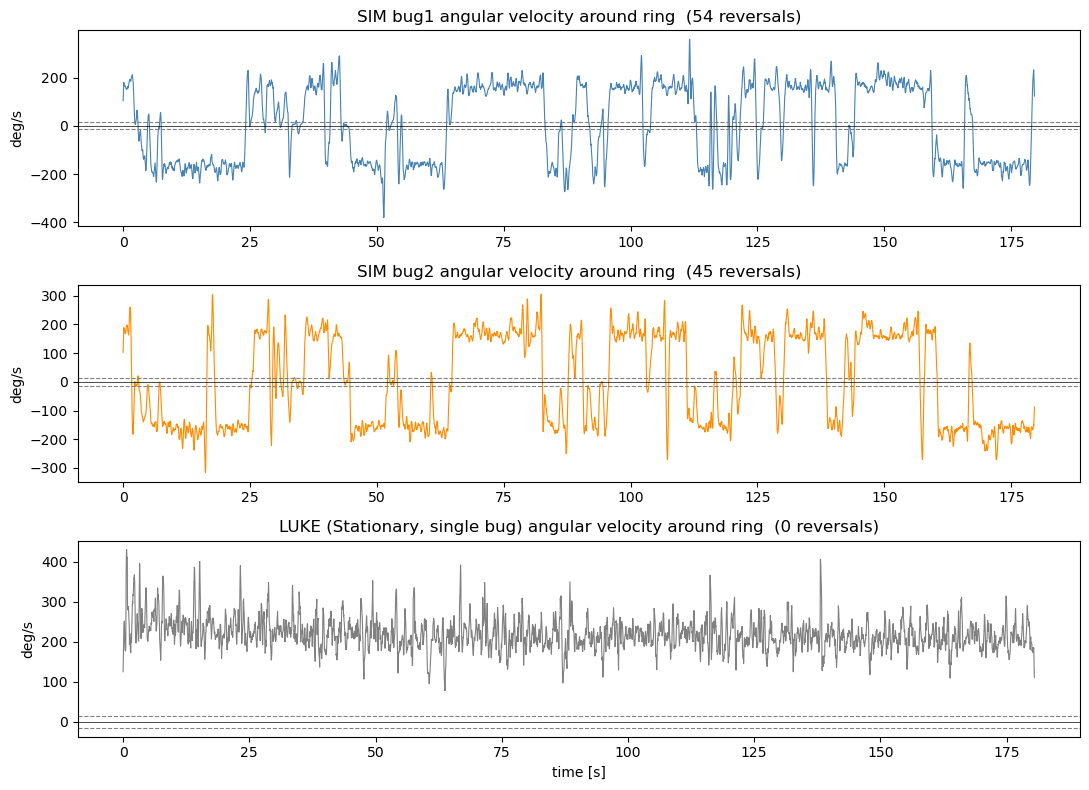

In [5]:
#  ORBITAL DIRECTION REVERSALS
import os

def _reversal_count(px, py, cx, cy, fps, smooth_s=0.3, v_thresh_degs=15.0):
    phi = np.unwrap(np.arctan2(py - cy, px - cx))
    dphi_degs = np.degrees(np.diff(phi)) * fps
    win = max(1, int(round(smooth_s * fps)))
    dphi_smooth = (np.convolve(dphi_degs, np.ones(win) / win, mode='same')
                   if win > 1 else dphi_degs)
    state = 0
    reversals = 0
    for v in dphi_smooth:
        if v > v_thresh_degs:
            new_state = 1
        elif v < -v_thresh_degs:
            new_state = -1
        else:
            new_state = state
        if state != 0 and new_state != state:
            reversals += 1
        state = new_state
    duration_s = len(phi) / fps
    return dict(n_reversals=reversals,
                rate_per_min=60.0 * reversals / duration_s if duration_s > 0 else float('nan'),
                duration_s=duration_s, dphi_smooth=dphi_smooth)

# SIM: per bug, reuse the 30 fps resampled positions from the cell above
sim_rev = []
for bi, (pos_b, bnd_b) in enumerate(positions_bug):
    frames = np.arange(nFrames)
    px_b = np.array([pos_b[f][0] for f in frames])
    py_b = np.array([pos_b[f][1] for f in frames])
    cx_b = np.array([bnd_b[f][0] for f in frames])
    cy_b = np.array([bnd_b[f][1] for f in frames])
    sim_rev.append(_reversal_count(px_b, py_b, cx_b, cy_b, FPS_ANALYSIS))

_P = np.genfromtxt(os.path.join('luke', 'Stationary', '_PositionCSV_3Min_Stationary.csv'),
                   delimiter=',', names=True, skip_header=1)
_B = np.genfromtxt(os.path.join('luke', 'Stationary', '_BoundaryCSV_3Min_Stationary.csv'),
                   delimiter=',', names=True, skip_header=1)
FPS_LUKE = 29.999169304892796

_fr  = _P['frame_abs'].astype(int)
_bx  = _P['bug1_cx_px']; _by = _P['bug1_cy_px']
_Bf  = _B['frame'].astype(int); _maxf = max(_fr.max(), _Bf.max()) + 2
_cxL = np.full(_maxf, np.nan); _cyL = np.full(_maxf, np.nan)
_cxL[_Bf] = _B['centre_x']; _cyL[_Bf] = _B['centre_y']
_m = np.isfinite(_cxL[_fr])
_bx, _by, _fr = _bx[_m], _by[_m], _fr[_m]
_rcxL = _cxL[_fr]; _rcyL = _cyL[_fr]

luke_rev = _reversal_count(_bx, _by, _rcxL, _rcyL, FPS_LUKE)

print(f"{'':10}{'duration':>10}{'reversals':>11}{'rate/min':>10}")
for bi, r in enumerate(sim_rev):
    print(f"  {'SIM bug'+str(bi+1):<8}{r['duration_s']:>10.1f}{r['n_reversals']:>11d}{r['rate_per_min']:>10.2f}")
_combined_rate = np.mean([r['rate_per_min'] for r in sim_rev])
print(f"  {'SIM avg':<8}{'':>10}{'':>11}{_combined_rate:>10.2f}")
print(f"  {'LUKE':<8}{luke_rev['duration_s']:>10.1f}{luke_rev['n_reversals']:>11d}{luke_rev['rate_per_min']:>10.2f}  (single bug)")

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharey=False)
for bi, r in enumerate(sim_rev):
    _t_sim = np.arange(len(r['dphi_smooth'])) / FPS_ANALYSIS
    axes[bi].plot(_t_sim, r['dphi_smooth'], color=bug_colors[bi], lw=0.8)
    axes[bi].axhline(15, color='gray', ls='--', lw=0.8); axes[bi].axhline(-15, color='gray', ls='--', lw=0.8)
    axes[bi].axhline(0, color='k', lw=0.5)
    axes[bi].set_ylabel('deg/s')
    axes[bi].set_title(f'SIM bug{bi+1} angular velocity around ring  ({r["n_reversals"]} reversals)')

_t_luke = np.arange(len(luke_rev['dphi_smooth'])) / FPS_LUKE
axes[2].plot(_t_luke, luke_rev['dphi_smooth'], color='gray', lw=0.8)
axes[2].axhline(15, color='gray', ls='--', lw=0.8); axes[2].axhline(-15, color='gray', ls='--', lw=0.8)
axes[2].axhline(0, color='k', lw=0.5)
axes[2].set_xlabel('time [s]'); axes[2].set_ylabel('deg/s')
axes[2].set_title(f'LUKE (Stationary, single bug) angular velocity around ring  ({luke_rev["n_reversals"]} reversals)')

plt.tight_layout(); plt.show()

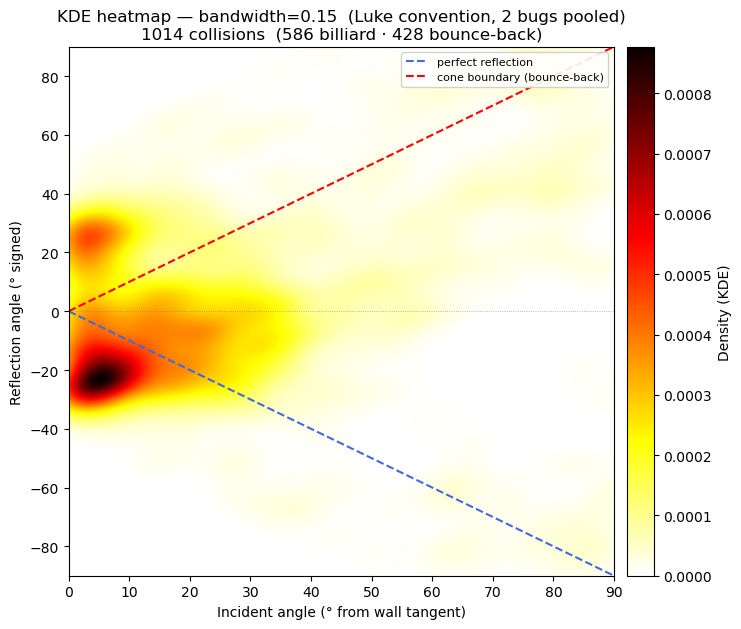

Collisions: 1014  |  billiard: 586  |  bounce-back: 428  |  bounce-back fraction: 0.42
Median incident: 16.4°   median reflection: -4.5°
Luke real (Stationary, single bug): bb 0.42  |  median incidence 15.8°  |  476 collisions


In [6]:
#  INCIDENCE vs REFLECTION HEATMAP  (Luke's EXACT convention, both bugs pooled)
# ══════════════════════════════════════════════════════════
from scipy.stats import gaussian_kde

bw      = 0.15
gridres = 300

if inc_deg.size < 2:
    print("Not enough collisions for a heatmap — increase t_end.")
else:
    incident   = inc_deg
    reflection = ref_deg

    n_billiard   = int(np.sum(reflection <  0))
    n_bounceback = int(np.sum(reflection >= 0))

    kde = gaussian_kde(np.vstack([incident, reflection]), bw_method=bw)
    xg = np.linspace(0, 90, gridres)
    yg = np.linspace(-90, 90, gridres)
    XG, YG = np.meshgrid(xg, yg)
    ZZ = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)

    fig, ax = plt.subplots(figsize=(7.6, 6.4))
    im = ax.imshow(ZZ, origin='lower', extent=[0, 90, -90, 90],
                   aspect='auto', cmap='hot_r', interpolation='bilinear')
    ax.plot([0, 90], [0, -90], color='royalblue', lw=1.5, ls='--',
            label='perfect reflection')
    ax.plot([0, 90], [0,  90], color='red', lw=1.5, ls='--',
            label='cone boundary (bounce-back)')
    ax.axhline(0, color='gray', lw=0.6, ls=':', alpha=0.7)

    ax.set_xlim(0, 90); ax.set_ylim(-90, 90)
    ax.set_xlabel('Incident angle (° from wall tangent)')
    ax.set_ylabel('Reflection angle (° signed)')
    ax.set_title(f'KDE heatmap — bandwidth={bw}  (Luke convention, 2 bugs pooled)\n'
                 f'{inc_deg.size} collisions  '
                 f'({n_billiard} billiard · {n_bounceback} bounce-back)')
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    cb = fig.colorbar(im, ax=ax, pad=0.02); cb.set_label('Density (KDE)')
    plt.tight_layout(); plt.show()

    print(f"Collisions: {inc_deg.size}  |  billiard: {n_billiard}  "
          f"|  bounce-back: {n_bounceback}  "
          f"|  bounce-back fraction: {n_bounceback/inc_deg.size:.2f}")
    print(f"Median incident: {np.median(incident):.1f}°   "
          f"median reflection: {np.median(reflection):.1f}°")
    print(f"Luke real (Stationary, single bug): bb 0.42  |  median incidence 15.8°  |  476 collisions")

bug1 centroid radius [mm]: median 55.1  p90 61.1  (wall at 66.7)
bug2 centroid radius [mm]: median 56.1  p90 61.4  (wall at 66.7)


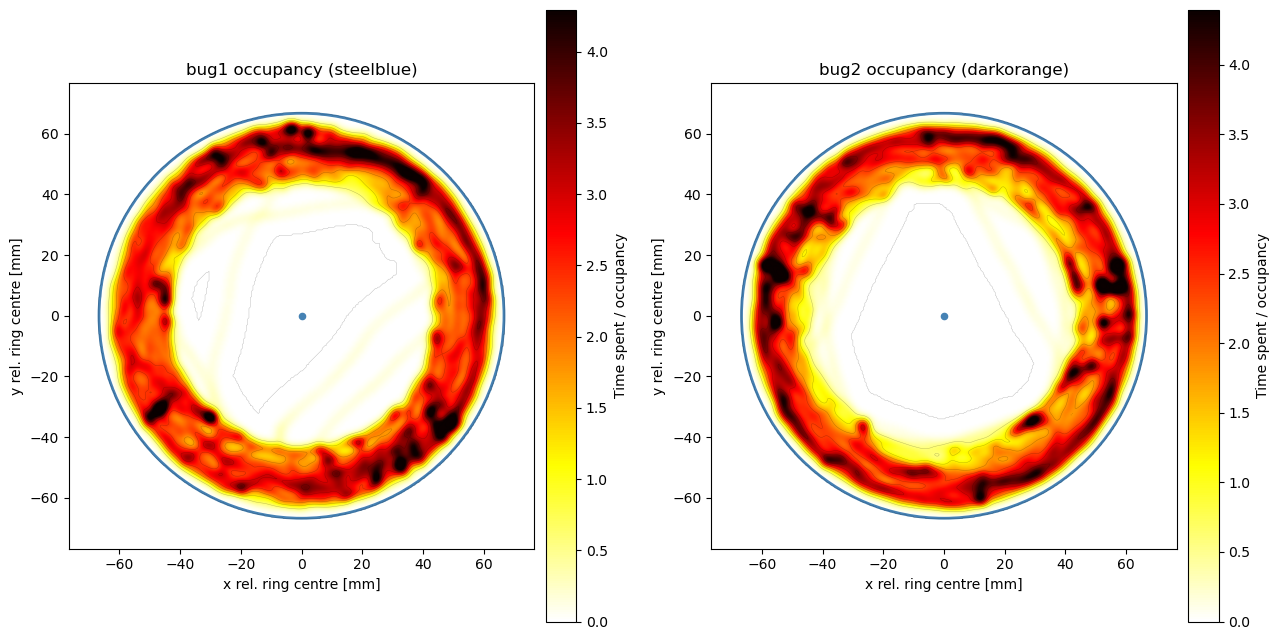

In [7]:
#  BUG POSITION-OCCUPANCY HEATMAP
from scipy.ndimage import gaussian_filter

BINS = 350
BLUR = 3.5
R_ring_mm = R_ring * 1e3

step = max(1, Y.shape[0] // 90000)
lim  = R_ring_mm * 1.15
edges = np.linspace(-lim, lim, BINS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for bi, off in enumerate((0, 6)):
    occ_x = (Y[::step, off+0] - Y[::step, 12]) * 1e3
    occ_y = (Y[::step, off+1] - Y[::step, 13]) * 1e3
    Hocc, xe, ye = np.histogram2d(occ_x, occ_y, bins=[edges, edges])
    Hocc = gaussian_filter(Hocc, sigma=BLUR)
    xc = (xe[:-1] + xe[1:]) / 2; yc = (ye[:-1] + ye[1:]) / 2
    XX, YY = np.meshgrid(xc, yc, indexing='ij')
    Hocc = np.where(np.hypot(XX, YY) <= R_ring_mm, Hocc, np.nan)
    vmax = np.nanpercentile(Hocc, 99)

    ax = axes[bi]
    im = ax.imshow(Hocc.T, origin='lower', extent=[-lim, lim, -lim, lim],
                   cmap='hot_r', vmin=0, vmax=vmax, interpolation='bilinear')
    ax.contour(XX, YY, np.nan_to_num(Hocc), levels=10, colors='black',
               linewidths=0.35, alpha=0.25)
    ax.add_patch(plt.Circle((0, 0), R_ring_mm, fill=False, edgecolor='steelblue', lw=2))
    ax.scatter([0], [0], s=20, c='steelblue')
    ax.set_aspect('equal'); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('x rel. ring centre [mm]')
    ax.set_ylabel('y rel. ring centre [mm]')
    ax.set_title(f'bug{bi+1} occupancy ({bug_colors[bi]})')
    cb = fig.colorbar(im, ax=ax, pad=0.02)
    cb.set_label('Time spent / occupancy')

    occ_r = np.hypot(occ_x, occ_y)
    print(f"bug{bi+1} centroid radius [mm]: median {np.median(occ_r):.1f}  "
          f"p90 {np.percentile(occ_r, 90):.1f}  (wall at {R_ring_mm:.1f})")

plt.tight_layout(); plt.show()

Narrow sweep of sigma_ang_coll, 5 collision-noise seeds averaged per point (t_end=120s each, two bugs pooled)

  sigma_ang=  4.0deg  n_coll~  630  med_inc= 12.2°(±1.4)  std_inc= 19.8°(±1.9)  bb=0.36(±0.03)
  sigma_ang=  5.0deg  n_coll~  633  med_inc= 14.1°(±1.1)  std_inc= 21.5°(±0.7)  bb=0.40(±0.03)
  sigma_ang=  6.0deg  n_coll~  641  med_inc= 13.0°(±1.8)  std_inc= 20.1°(±1.9)  bb=0.40(±0.03)
  sigma_ang=  7.0deg  n_coll~  645  med_inc= 14.0°(±2.1)  std_inc= 21.4°(±1.2)  bb=0.42(±0.02)
  sigma_ang=  8.0deg  n_coll~  668  med_inc= 15.7°(±2.3)  std_inc= 22.5°(±1.0)  bb=0.45(±0.02)
  sigma_ang=  9.0deg  n_coll~  677  med_inc= 18.5°(±2.8)  std_inc= 23.6°(±0.9)  bb=0.49(±0.01)
  sigma_ang= 10.0deg  n_coll~  693  med_inc= 19.0°(±2.0)  std_inc= 24.1°(±1.3)  bb=0.48(±0.03)
  sigma_ang= 11.0deg  n_coll~  714  med_inc= 21.1°(±1.5)  std_inc= 24.7°(±0.8)  bb=0.51(±0.03)
  sigma_ang= 12.0deg  n_coll~  720  med_inc= 23.2°(±1.8)  std_inc= 25.0°(±0.6)  bb=0.51(±0.01)

  Luke real (Stationary, single b

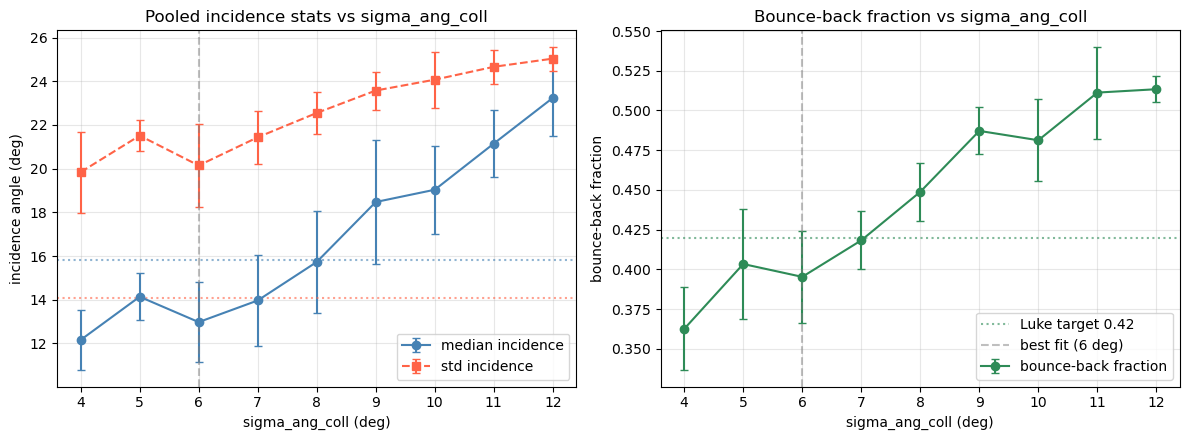

In [9]:
#  COLLISION-NOISE SWEEP

SIGMA_ANG_SWEEP_FINE = np.deg2rad([4, 5, 6, 7, 8, 9, 10, 11, 12])
N_SEEDS_FINE         = 5
T_NOISE_SWEEP        = 120.0
NOISE_SWEEP_SEED     = 0

_n_steps_ns = int(round(T_NOISE_SWEEP / dt_fix))
_rng_ns     = np.random.default_rng(NOISE_SWEEP_SEED)
_noise_ns   = _rng_ns.standard_normal((_n_steps_ns, 6))

def _run_and_analyse(sigma_ang, seed):
    Yn, _ = integrate_hard_2bug(y0, _n_steps_ns, dt_fix, _noise_ns, sigma_v, sigma_om,
                                M_bug, I_bug, k_motor, v_motor, L0, R_ring,
                                gamma_bug, e_rest, mu_fric,
                                e_rest_bb, mu_fric_bb, r_cut_bug,
                                sigma_ang, seed,
                                ring_fixed, M_ring, I_ring, gamma_ring)
    incs, refs = [], []
    for off in (0, 6):
        nFn, pos_n, bnd_n = _resample_positions_boundary(Yn, off)
        starts_n = _sim_collision_frames(Yn, off)
        cf_raw_n = sorted(set(
            int(round(s / STEP_PER_FRAME)) for s in starts_n
            if -INC_OFFSET <= s // STEP_PER_FRAME < nFn - max(REFLECTION_OFFSETS) - 1))
        cf_n = _refractory(cf_raw_n)
        inc_n, ref_n, _ = analyse_luke(pos_n, bnd_n, cf_n)
        incs.append(inc_n); refs.append(ref_n)
    inc_all = np.concatenate(incs); ref_all = np.concatenate(refs)
    if inc_all.size == 0:
        return dict(n_coll=0, med_inc=float('nan'), std_inc=float('nan'), bb_frac=float('nan'))
    return dict(n_coll=int(inc_all.size), med_inc=float(np.median(inc_all)),
                std_inc=float(np.std(inc_all)), bb_frac=float(np.mean(ref_all >= 0)))

print(f"Narrow sweep of sigma_ang_coll, {N_SEEDS_FINE} collision-noise seeds "
      f"averaged per point (t_end={T_NOISE_SWEEP:g}s each, two bugs pooled)\n")

rows_fine = []
for _sa in SIGMA_ANG_SWEEP_FINE:
    _reps = [_run_and_analyse(_sa, seed) for seed in range(N_SEEDS_FINE)]
    _med_incs = np.array([r['med_inc'] for r in _reps])
    _std_incs = np.array([r['std_inc'] for r in _reps])
    _bb_fracs = np.array([r['bb_frac'] for r in _reps])
    _n_colls  = np.array([r['n_coll'] for r in _reps])
    row = dict(sigma_ang_deg=np.degrees(_sa),
               med_inc=float(_med_incs.mean()), med_inc_sd=float(_med_incs.std()),
               std_inc=float(_std_incs.mean()), std_inc_sd=float(_std_incs.std()),
               bb_frac=float(_bb_fracs.mean()), bb_frac_sd=float(_bb_fracs.std()),
               n_coll=float(_n_colls.mean()))
    rows_fine.append(row)
    print(f"  sigma_ang={row['sigma_ang_deg']:5.1f}deg  n_coll~{row['n_coll']:5.0f}  "
          f"med_inc={row['med_inc']:5.1f}°(±{row['med_inc_sd']:.1f})  "
          f"std_inc={row['std_inc']:5.1f}°(±{row['std_inc_sd']:.1f})  "
          f"bb={row['bb_frac']:.2f}(±{row['bb_frac_sd']:.2f})")

print(f"\n  Luke real (Stationary, single bug) target:  median incidence 15.8°  std 14.1°  bb 0.42")

_TARGET_MED, _TARGET_STD, _TARGET_BB = 15.8, 14.1, 0.42
for row in rows_fine:
    row['sse'] = (((row['med_inc'] - _TARGET_MED) / _TARGET_MED) ** 2 +
                  ((row['std_inc'] - _TARGET_STD) / _TARGET_STD) ** 2 +
                  ((row['bb_frac'] - _TARGET_BB) / _TARGET_BB) ** 2)

_best = min(rows_fine, key=lambda r: r['sse'])
print(f"\n  BEST FIT in this range: sigma_ang_coll = {_best['sigma_ang_deg']:.0f} deg  "
      f"(med_inc={_best['med_inc']:.1f}°, std_inc={_best['std_inc']:.1f}°, bb={_best['bb_frac']:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
_a_deg = [r['sigma_ang_deg'] for r in rows_fine]
_meds  = [r['med_inc'] for r in rows_fine]; _meds_sd = [r['med_inc_sd'] for r in rows_fine]
_stds  = [r['std_inc'] for r in rows_fine]; _stds_sd = [r['std_inc_sd'] for r in rows_fine]
_bbs   = [r['bb_frac'] for r in rows_fine]; _bbs_sd  = [r['bb_frac_sd'] for r in rows_fine]

axes[0].errorbar(_a_deg, _meds, yerr=_meds_sd, fmt='o-', color='steelblue', label='median incidence', capsize=3)
axes[0].errorbar(_a_deg, _stds, yerr=_stds_sd, fmt='s--', color='tomato', label='std incidence', capsize=3)
axes[0].axhline(_TARGET_MED, color='steelblue', ls=':', alpha=0.6)
axes[0].axhline(_TARGET_STD, color='tomato', ls=':', alpha=0.6)
axes[0].axvline(_best['sigma_ang_deg'], color='gray', ls='--', alpha=0.5)
axes[0].set_xlabel('sigma_ang_coll (deg)'); axes[0].set_ylabel('incidence angle (deg)')
axes[0].set_title('Pooled incidence stats vs sigma_ang_coll'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].errorbar(_a_deg, _bbs, yerr=_bbs_sd, fmt='o-', color='seagreen', label='bounce-back fraction', capsize=3)
axes[1].axhline(_TARGET_BB, color='seagreen', ls=':', alpha=0.6, label='Luke target 0.42')
axes[1].axvline(_best['sigma_ang_deg'], color='gray', ls='--', alpha=0.5, label=f"best fit ({_best['sigma_ang_deg']:.0f} deg)")
axes[1].set_xlabel('sigma_ang_coll (deg)'); axes[1].set_ylabel('bounce-back fraction')
axes[1].set_title('Bounce-back fraction vs sigma_ang_coll'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()